In [ ]:
import glob, json, os
import numpy as np
from dataclasses import replace

from fashion_retrieval.configs.config import CONFIG
from fashion_retrieval.indexer.storage import VectorStore
from fashion_retrieval.retriever.rerank import rerank

cfg = replace(CONFIG, rerank_fields=(
    "top", "bottom", "dress", "outerwear", "shoes",
    "accessories", "action", "style", "environment",
))
ATTR_DIR = "data/qwen3_vl_metadata"
IMAGES_DIR = "data/sampled_images"
CURATED_DIR = "data/curated"             
IMG_EMB_DIR = "data/siglip_image_emb"  

In [ ]:
import torch
from transformers import SiglipModel, AutoProcessor

SIGLIP_MODEL = "google/siglip2-base-patch16-224"

class SiglipTextEmbedder:
    def __init__(self, model_id=SIGLIP_MODEL, device="cpu", batch_size=64):
        self.device, self.batch_size = device, batch_size
        self.model = SiglipModel.from_pretrained(model_id).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_id)

    @torch.inference_mode()
    def _encode(self, texts):
        chunks = []
        for i in range(0, len(texts), self.batch_size):
            # SigLIP's text tower is a FIXED 64-token context — pad/truncate to max_length.
            inputs = self.processor(
                text=texts[i:i + self.batch_size], return_tensors="pt",
                padding="max_length", truncation=True, max_length=64,
            ).to(self.device)
            feats = self.model.get_text_features(**inputs)
            feats = torch.nn.functional.normalize(feats, p=2, dim=-1)  
            chunks.append(feats.cpu())
        return torch.cat(chunks).numpy().astype("float32")

    def embed_documents(self, captions):
        return self._encode(list(captions))

    def embed_query(self, query):
        return self._encode([query])[0]

In [ ]:
raw = []
for fp in sorted(glob.glob(f"{ATTR_DIR}/*.json")):
    with open(fp) as f:
        r = json.load(f)
    if r.get("_parse_error") or r.get("_exception"):
        continue
    stem = os.path.splitext(os.path.basename(fp))[0]
    r["image_path"] = f"{IMAGES_DIR}/{stem}.jpg"
    raw.append(r)

print(f"loaded {len(raw)} usable attribute records")

loaded 460 usable attribute records


In [ ]:
def _phrase(*parts):
    words, seen = [], set()
    for p in parts:
        if not p:
            continue
        for w in str(p).strip().split():
            if w and w.lower() not in seen:
                seen.add(w.lower())
                words.append(w)
    return " ".join(words)

def _feat(rec, slot):
    return " ".join(str(x) for x in (rec.get(f"{slot}_features") or []) if x)

def _accessories(rec):
    out = []
    for a in rec.get("accessories") or []:
        if isinstance(a, dict):
            p = _phrase(a.get("color"), a.get("item"))
            if p:
                out.append(p)
        elif a:
            out.append(str(a))
    return out

def flat_attrs(rec):
    return {
        "top": _phrase(rec.get("top_color"), _feat(rec, "top"), rec.get("top")),
        "bottom": _phrase(rec.get("bottom_color"), _feat(rec, "bottom"), rec.get("bottom")),
        "dress": _phrase(rec.get("dress_color"), _feat(rec, "dress"), rec.get("dress")),
        "outerwear": _phrase(rec.get("outerwear_color"), _feat(rec, "outerwear"), rec.get("outerwear")),
        "shoes": _phrase(rec.get("shoes_color"), rec.get("shoes")),
        "accessories": ", ".join(_accessories(rec)),
        "action": rec.get("action") or "",
        "style": rec.get("style") or "",
        "environment": rec.get("environment") or "",
    }

def attrs_to_text(rec):
    a = flat_attrs(rec)
    garments = [a[k] for k in ("top", "bottom", "dress", "outerwear", "shoes") if a[k]]
    bits = []
    if garments:
        bits.append("A person wearing " + ", ".join(garments))
    if a["accessories"]:
        bits.append("with " + a["accessories"])
    if a["action"]:
        bits.append(a["action"])
    if a["style"]:
        bits.append(a["style"] + " style")
    if a["environment"]:
        bits.append("in " + a["environment"])
    return (", ".join(bits) + ".") if bits else "An unspecified fashion image."

def _resolve_image(stem):
    for cand in (f"{IMAGES_DIR}/{stem}.jpg", f"{CURATED_DIR}/{stem}.jpg",
                 f"{CURATED_DIR}/{stem}.jpeg", f"{CURATED_DIR}/{stem}.png"):
        if os.path.exists(cand):
            return cand
    return f"{IMAGES_DIR}/{stem}.jpg"

records = []
for r in raw:
    stem = os.path.splitext(os.path.basename(r["image_path"]))[0]
    records.append({
        "id": stem,                       # join key: metadata <-> image emb <-> pixels
        "image_path": _resolve_image(stem),
        "caption": attrs_to_text(r),
        "attributes": flat_attrs(r),
    })
for r in records[:3]:
    print(r["id"], "->", r["caption"])

image_00000 -> A person wearing beige polka dot lace trim sleeveless dress, green sandals, with gold bracelet, posing, casual style, in forest path.
image_00001 -> A person wearing gray heathered long-sleeved dress, standing, minimalist casual style, in studio.
image_00002 -> A person wearing black asymmetric sleeveless dress, black high heels, walking, elegant evening style, in fashion runway.


In [ ]:
emb = SiglipTextEmbedder()
vecs = emb.embed_documents([r["caption"] for r in records])
store = VectorStore(cfg).create(vecs, records)
print(f"indexed {store.index.ntotal} vectors (dim={vecs.shape[1]})")

indexed 460 vectors (dim=768)


In [ ]:
img_vecs = np.stack([
    np.load(f"{IMG_EMB_DIR}/{r['id']}.npy") for r in records
]).astype("float32")
assert len(img_vecs) == len(records), "image vectors must be row-aligned to records"

image_store = VectorStore(cfg).create(img_vecs, records)
id2row = {r["id"]: i for i, r in enumerate(records)}
print(f"image index: {image_store.index.ntotal} vectors (dim={img_vecs.shape[1]}) "
      f"| aligned to {len(records)} caption records")

image index: 460 vectors (dim=768) | aligned to 460 caption records


In [ ]:
def _full_scores(index, q, n):
    """Row-indexed similarity of q against every vector in `index` (flat IP == cosine)."""
    s, ids = index.search(q.reshape(1, -1).astype("float32"), n)
    out = np.zeros(n, dtype="float32")
    out[ids[0]] = s[0]                     
    return out

def search(query, k=cfg.top_k, a=0.5):
    q = emb.embed_query(query)
    n = len(records)
    text_sim = _full_scores(store.index, q, n)
    image_sim = _full_scores(image_store.index, q, n)
    fused = a * text_sim + (1.0 - a) * image_sim

    top = np.argsort(-fused)[:cfg.top_candidates]         
    candidates = [(records[row], float(fused[row])) for row in top]
    re_ranked = rerank(query, candidates, cfg)              

    hits = []
    for rec, final, debug in re_ranked[:k]:
        row = id2row[rec["id"]]
        hits.append({
            "id": rec["id"],
            "image_path": rec["image_path"],
            "caption": rec["caption"],
            "score": round(final, 4),                      
            "fused": round(float(fused[row]), 4),
            "text_sim": round(float(text_sim[row]), 4),
            "image_sim": round(float(image_sim[row]), 4),
            "matched": debug["matched"],
        })
    return hits

In [ ]:
from PIL import Image
from IPython.display import display

def show(query, k=5, a=0.5, thumb=200):
    hits = search(query, k, a=a)
    print(f'\nQuery: "{query}"   (a={a}: {a:.0%} text / {1-a:.0%} image)')
    for i, h in enumerate(hits, 1):
        m = ("  matched: " + ", ".join(h["matched"])) if h["matched"] else ""
        print(f"{i}. score={h['score']:.3f} "
              f"(fused={h['fused']:.3f} = text {h['text_sim']:.2f} / img {h['image_sim']:.2f})  "
              f"{h['image_path']}{m}")
    imgs = [Image.open(h["image_path"]).convert("RGB") for h in hits]
    thumbs = []
    for im in imgs:
        im.thumbnail((thumb, thumb))
        thumbs.append(im)
    pad, h_max = 6, max((im.height for im in thumbs), default=0)
    w_total = sum(im.width for im in thumbs) + pad * (len(thumbs) + 1)
    sheet = Image.new("RGB", (w_total, h_max + 2 * pad), "white")
    x = pad
    for im in thumbs:
        sheet.paste(im, (x, pad))
        x += im.width + pad
    display(sheet)


Query: "A person in a bright yellow raincoat."   (a=0.5: 50% text / 50% image)
1. score=0.563 (fused=0.463 = text 0.78 / img 0.15)  data/curated/images2.jpg  matched: raincoat, yellow
2. score=0.518 (fused=0.418 = text 0.71 / img 0.13)  data/curated/images.jpg  matched: raincoat, yellow
3. score=0.502 (fused=0.402 = text 0.64 / img 0.16)  data/curated/images3.jpg  matched: raincoat, yellow
4. score=0.484 (fused=0.384 = text 0.61 / img 0.15)  data/curated/images4.jpg  matched: raincoat, yellow
5. score=0.428 (fused=0.378 = text 0.66 / img 0.10)  data/sampled_images/image_00219.jpg  matched: yellow


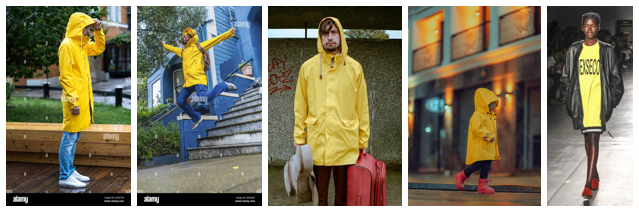


Query: "Professional business attire inside a modern office."   (a=0.5: 50% text / 50% image)
1. score=0.448 (fused=0.398 = text 0.66 / img 0.14)  data/curated/images office4.jpg  matched: business, office
2. score=0.428 (fused=0.378 = text 0.61 / img 0.15)  data/curated/images office3.jpg  matched: business, office
3. score=0.418 (fused=0.393 = text 0.66 / img 0.12)  data/curated/images office2.jpg  matched: office
4. score=0.394 (fused=0.344 = text 0.59 / img 0.09)  data/curated/images tie4.jpg  matched: business, office
5. score=0.384 (fused=0.359 = text 0.64 / img 0.08)  data/sampled_images/image_00343.jpg  matched: business


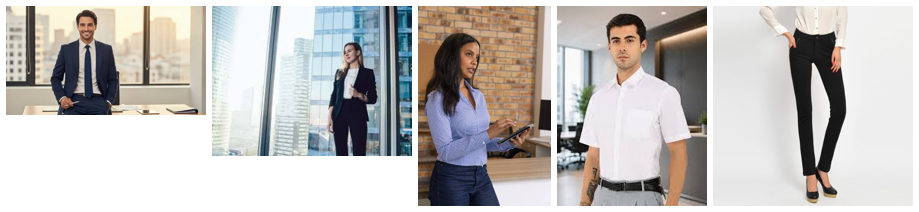


Query: "Someone wearing a blue shirt sitting on a park bench."   (a=0.5: 50% text / 50% image)
1. score=0.559 (fused=0.439 = text 0.72 / img 0.16)  data/curated/images park.jpg  matched: blue, park, shirt, sitting
2. score=0.452 (fused=0.332 = text 0.52 / img 0.14)  data/curated/images park3.jpg  matched: blue, park, shirt, sitting
3. score=0.431 (fused=0.311 = text 0.48 / img 0.15)  data/curated/images park2.jpg  matched: blue, park, shirt, sitting
4. score=0.389 (fused=0.299 = text 0.52 / img 0.07)  data/sampled_images/image_00238.jpg  matched: blue, shirt, sitting
5. score=0.378 (fused=0.258 = text 0.43 / img 0.09)  data/curated/images park4.jpg  matched: blue, park, shirt, sitting


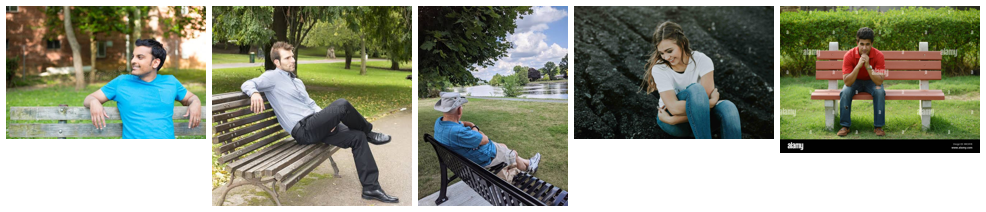


Query: "Casual weekend outfit for a city walk."   (a=0.5: 50% text / 50% image)
1. score=0.459 (fused=0.421 = text 0.76 / img 0.08)  data/sampled_images/image_00394.jpg  matched: casual
2. score=0.459 (fused=0.384 = text 0.63 / img 0.13)  data/sampled_images/image_00309.jpg  matched: casual, city
3. score=0.447 (fused=0.372 = text 0.61 / img 0.13)  data/sampled_images/image_00308.jpg  matched: casual, city
4. score=0.444 (fused=0.369 = text 0.62 / img 0.11)  data/sampled_images/image_00442.jpg  matched: casual, city
5. score=0.442 (fused=0.405 = text 0.69 / img 0.12)  data/sampled_images/image_00157.jpg  matched: casual


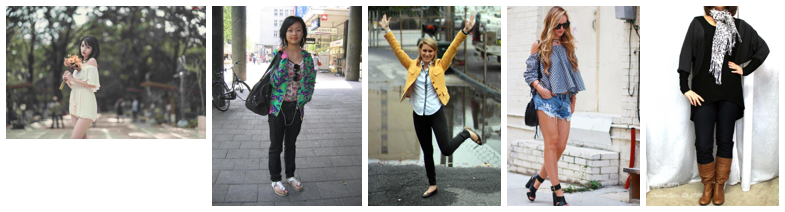


Query: "A red tie and a white shirt in a formal setting."   (a=0.5: 50% text / 50% image)
1. score=0.476 (fused=0.351 = text 0.61 / img 0.09)  data/sampled_images/image_00108.jpg  matched: formal, red, shirt, tie, white
2. score=0.469 (fused=0.369 = text 0.65 / img 0.09)  data/sampled_images/image_00339.jpg  matched: formal, red, shirt, white
3. score=0.436 (fused=0.361 = text 0.62 / img 0.10)  data/curated/images tie2.jpg  matched: red, shirt, white
4. score=0.435 (fused=0.360 = text 0.56 / img 0.16)  data/curated/images tie3.jpg  matched: formal, shirt, white
5. score=0.428 (fused=0.353 = text 0.60 / img 0.10)  data/curated/images office4.jpg  matched: formal, shirt, white


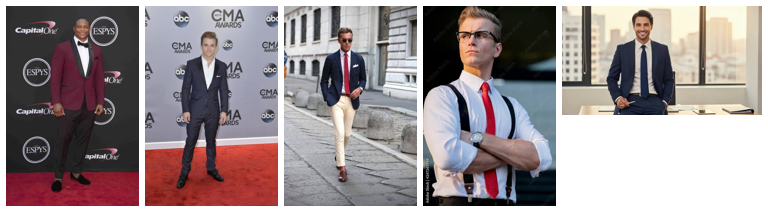

In [ ]:
EVAL_QUERIES = [
    "A person in a bright yellow raincoat.",
    "Professional business attire inside a modern office.",
    "Someone wearing a blue shirt sitting on a park bench.",
    "Casual weekend outfit for a city walk.",
    "A red tie and a white shirt in a formal setting.",
]
for q in EVAL_QUERIES:
    show(q)